# Analyse de l'Économie du Brésil

## Préparation des données

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_eco=pd.read_csv('Global Economy Indicators.csv')
df_eco.head()

,CountryID,Country,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
0,4,Afghanistan,1970,0.044998,0.044998,10752971,Afghani,164,8.699174e+08,NaN,...,1.551094e+09,195277226.0,370146827.0,376690811.0,127747843.0,1.731454e+09,83917200.0,226387091.0,1.766528e+09,1.731436e+09
1,4,Afghanistan,1971,0.044998,0.044998,11015857,Afghani,168,9.108281e+08,NaN,...,1.675426e+09,276296480.0,387549502.0,394401164.0,133754097.0,1.812857e+09,87860382.0,237019196.0,1.850122e+09,1.812838e+09
2,4,Afghanistan,1972,0.044998,0.044998,11286753,Afghani,149,8.279453e+08,NaN,...,1.498812e+09,290370350.0,352284669.0,358512865.0,121582672.0,1.647918e+09,79864525.0,215477287.0,1.683948e+09,1.647900e+09
3,4,Afghanistan,1973,0.044998,0.044998,11575305,Afghani,150,8.554869e+08,NaN,...,1.508024e+09,262962880.0,364010279.0,370445793.0,125630236.0,1.702735e+09,82528885.0,222624293.0,1.739998e+09,1.702716e+09
4,4,Afghanistan,1974,0.044998,0.044998,11869879,Afghani,177,1.035913e+09,NaN,...,1.778819e+09,305679151.0,440760406.0,448552790.0,152119162.0,2.061752e+09,99918604.0,269525910.0,2.106420e+09,2.061729e+09


In [3]:
# Indicateurs de Change et Monnaie
indicateurs_change_monnaie = [
    ' AMA exchange rate ',
    ' IMF based exchange rate ',
    ' Currency '
]

# Indicateurs Démographiques
indicateurs_demographiques = [
    ' Population '
]

# Indicateurs de Revenu et Production
indicateurs_revenu_production = [
    ' Per capita GNI ',
    ' Gross National Income(GNI) in USD ',
    ' Gross Domestic Product (GDP) '
]

# Composantes du PIB
composantes_pib = [
    ' Exports of goods and services ',
    ' Imports of goods and services ',
    ' Final consumption expenditure ',
    ' Household consumption expenditure (including Non-profit institutions serving households) ',
    ' General government final consumption expenditure ',
    ' Gross capital formation ',
    ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ',
    ' Changes in inventories '
]

# Secteurs Économiques
secteurs_economiques = [
    ' Agriculture, hunting, forestry, fishing (ISIC A-B) ',
    ' Mining, Manufacturing, Utilities (ISIC C-E) ',
    ' Manufacturing (ISIC D) ',
    ' Construction (ISIC F) ',
    ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ',
    ' Transport, storage and communication (ISIC I) ',
    ' Other Activities (ISIC J-P) ',
    ' Total Value Added '
]

# Affichage des listes
print("Indicateurs de Change et Monnaie:", indicateurs_change_monnaie)
print("Indicateurs Démographiques:", indicateurs_demographiques)
print("Indicateurs de Revenu et Production:", indicateurs_revenu_production)
print("Composantes du PIB:", composantes_pib)
print("Secteurs Économiques:", secteurs_economiques)

Indicateurs de Change et Monnaie: [' AMA exchange rate ', ' IMF based exchange rate ', ' Currency ']
Indicateurs Démographiques: [' Population ']
Indicateurs de Revenu et Production: [' Per capita GNI ', ' Gross National Income(GNI) in USD ', ' Gross Domestic Product (GDP) ']
Composantes du PIB: [' Exports of goods and services ', ' Imports of goods and services ', ' Final consumption expenditure ', ' Household consumption expenditure (including Non-profit institutions serving households) ', ' General government final consumption expenditure ', ' Gross capital formation ', ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ', ' Changes in inventories ']
Secteurs Économiques: [' Agriculture, hunting, forestry, fishing (ISIC A-B) ', ' Mining, Manufacturing, Utilities (ISIC C-E) ', ' Manufacturing (ISIC D) ', ' Construction (ISIC F) ', ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ', ' Transport, storage and communication (ISIC I) ', ' Othe

In [4]:
# Dictionnaire de traduction des termes économiques
traduction = {
    ' AMA exchange rate ': 'Taux de change AMA',
    ' IMF based exchange rate ': 'Taux de change basé sur le FMI',
    ' Population ': 'Population',
    ' Currency ': 'Monnaie',
    ' Per capita GNI ': 'Revenu National Brut par habitant',
    ' Agriculture, hunting, forestry, fishing (ISIC A-B) ': 'Agriculture, chasse, sylviculture, pêche (ISIC A-B)',
    ' Changes in inventories ': 'Variations des stocks',
    ' Construction (ISIC F) ': 'Construction (ISIC F)',
    ' Exports of goods and services ': 'Exportations de biens et services',
    ' Final consumption expenditure ': 'Dépenses de consommation finale',
    ' General government final consumption expenditure ': 'Dépenses de consommation finale des administrations publiques',
    ' Gross capital formation ': 'Formation brute de capital',
    ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ': 'Formation brute de capital fixe (y compris les acquisitions moins les cessions de valeurs)',
    ' Household consumption expenditure (including Non-profit institutions serving households) ': 'Dépenses de consommation des ménages (y compris les institutions sans but lucratif au service des ménages)',
    ' Imports of goods and services ': 'Importations de biens et services',
    ' Manufacturing (ISIC D) ': 'Fabrication (ISIC D)',
    ' Mining, Manufacturing, Utilities (ISIC C-E) ': 'Mines, manufactures, services publics (ISIC C-E)',
    ' Other Activities (ISIC J-P) ': 'Autres activités (ISIC J-P)',
    ' Total Value Added ': 'Valeur ajoutée totale',
    ' Transport, storage and communication (ISIC I) ': 'Transport, entreposage et communication (ISIC I)',
    ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ': 'Commerce de gros, commerce de détail, restaurants et hôtels (ISIC G-H)',
    ' Gross National Income(GNI) in USD ': 'Revenu National Brut (RNB) en USD',
    ' Gross Domestic Product (GDP) ': 'Produit Intérieur Brut (PIB)'
}


In [5]:
pd.options.mode.chained_assignment = None

In [6]:
df_eco_brésil=df_eco[df_eco[' Country ']==' Brazil ']
df_eco_brésil.drop(' Country ',axis=1,inplace=True)
df_eco_brésil.drop(' CountryID ',axis=1,inplace=True)
df_eco_brésil.head()

,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,Construction (ISIC F),Exports of goods and services,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
1032,1970,1.990000e-12,1.990000e-12,96369875,Brazilian Real,360,3.521386e+09,2.154384e+08,1.509165e+09,2.550525e+09,...,2.439791e+10,2.499771e+09,8.551937e+09,9.054992e+09,1.056416e+10,3.169247e+10,1.509165e+09,5.030551e+09,3.471080e+10,3.538055e+10
1033,1971,2.290000e-12,2.290000e-12,98766288,Brazilian Real,394,4.370208e+09,9.741192e+07,2.185104e+09,2.658869e+09,...,2.737723e+10,3.040288e+09,1.005148e+10,1.136254e+10,1.092552e+10,3.583570e+10,1.311062e+09,5.681270e+09,3.889485e+10,3.951805e+10
1034,1972,2.570000e-12,2.570000e-12,101194394,Brazilian Real,496,5.451798e+09,3.335410e+08,2.725899e+09,3.553844e+09,...,3.541196e+10,4.644165e+09,1.324008e+10,1.440832e+10,1.440832e+10,4.595087e+10,1.947071e+09,7.009455e+09,5.023443e+10,5.086348e+10
1035,1973,2.650000e-12,2.650000e-12,103666904,Brazilian Real,684,7.921717e+09,4.846544e+08,3.772246e+09,5.737665e+09,...,5.031179e+10,6.373289e+09,2.037013e+10,2.187903e+10,1.886123e+10,6.563708e+10,2.640572e+09,1.018506e+10,7.091823e+10,7.201195e+10
1036,1974,2.940000e-12,2.940000e-12,106167372,Brazilian Real,859,9.869447e+09,1.467543e+09,5.104887e+09,7.246999e+09,...,6.671022e+10,1.217621e+10,2.722606e+10,2.960834e+10,2.484378e+10,8.576209e+10,3.403258e+09,1.293238e+10,9.120731e+10,9.232293e+10


In [7]:
del df_eco

## Indicateurs du PIB

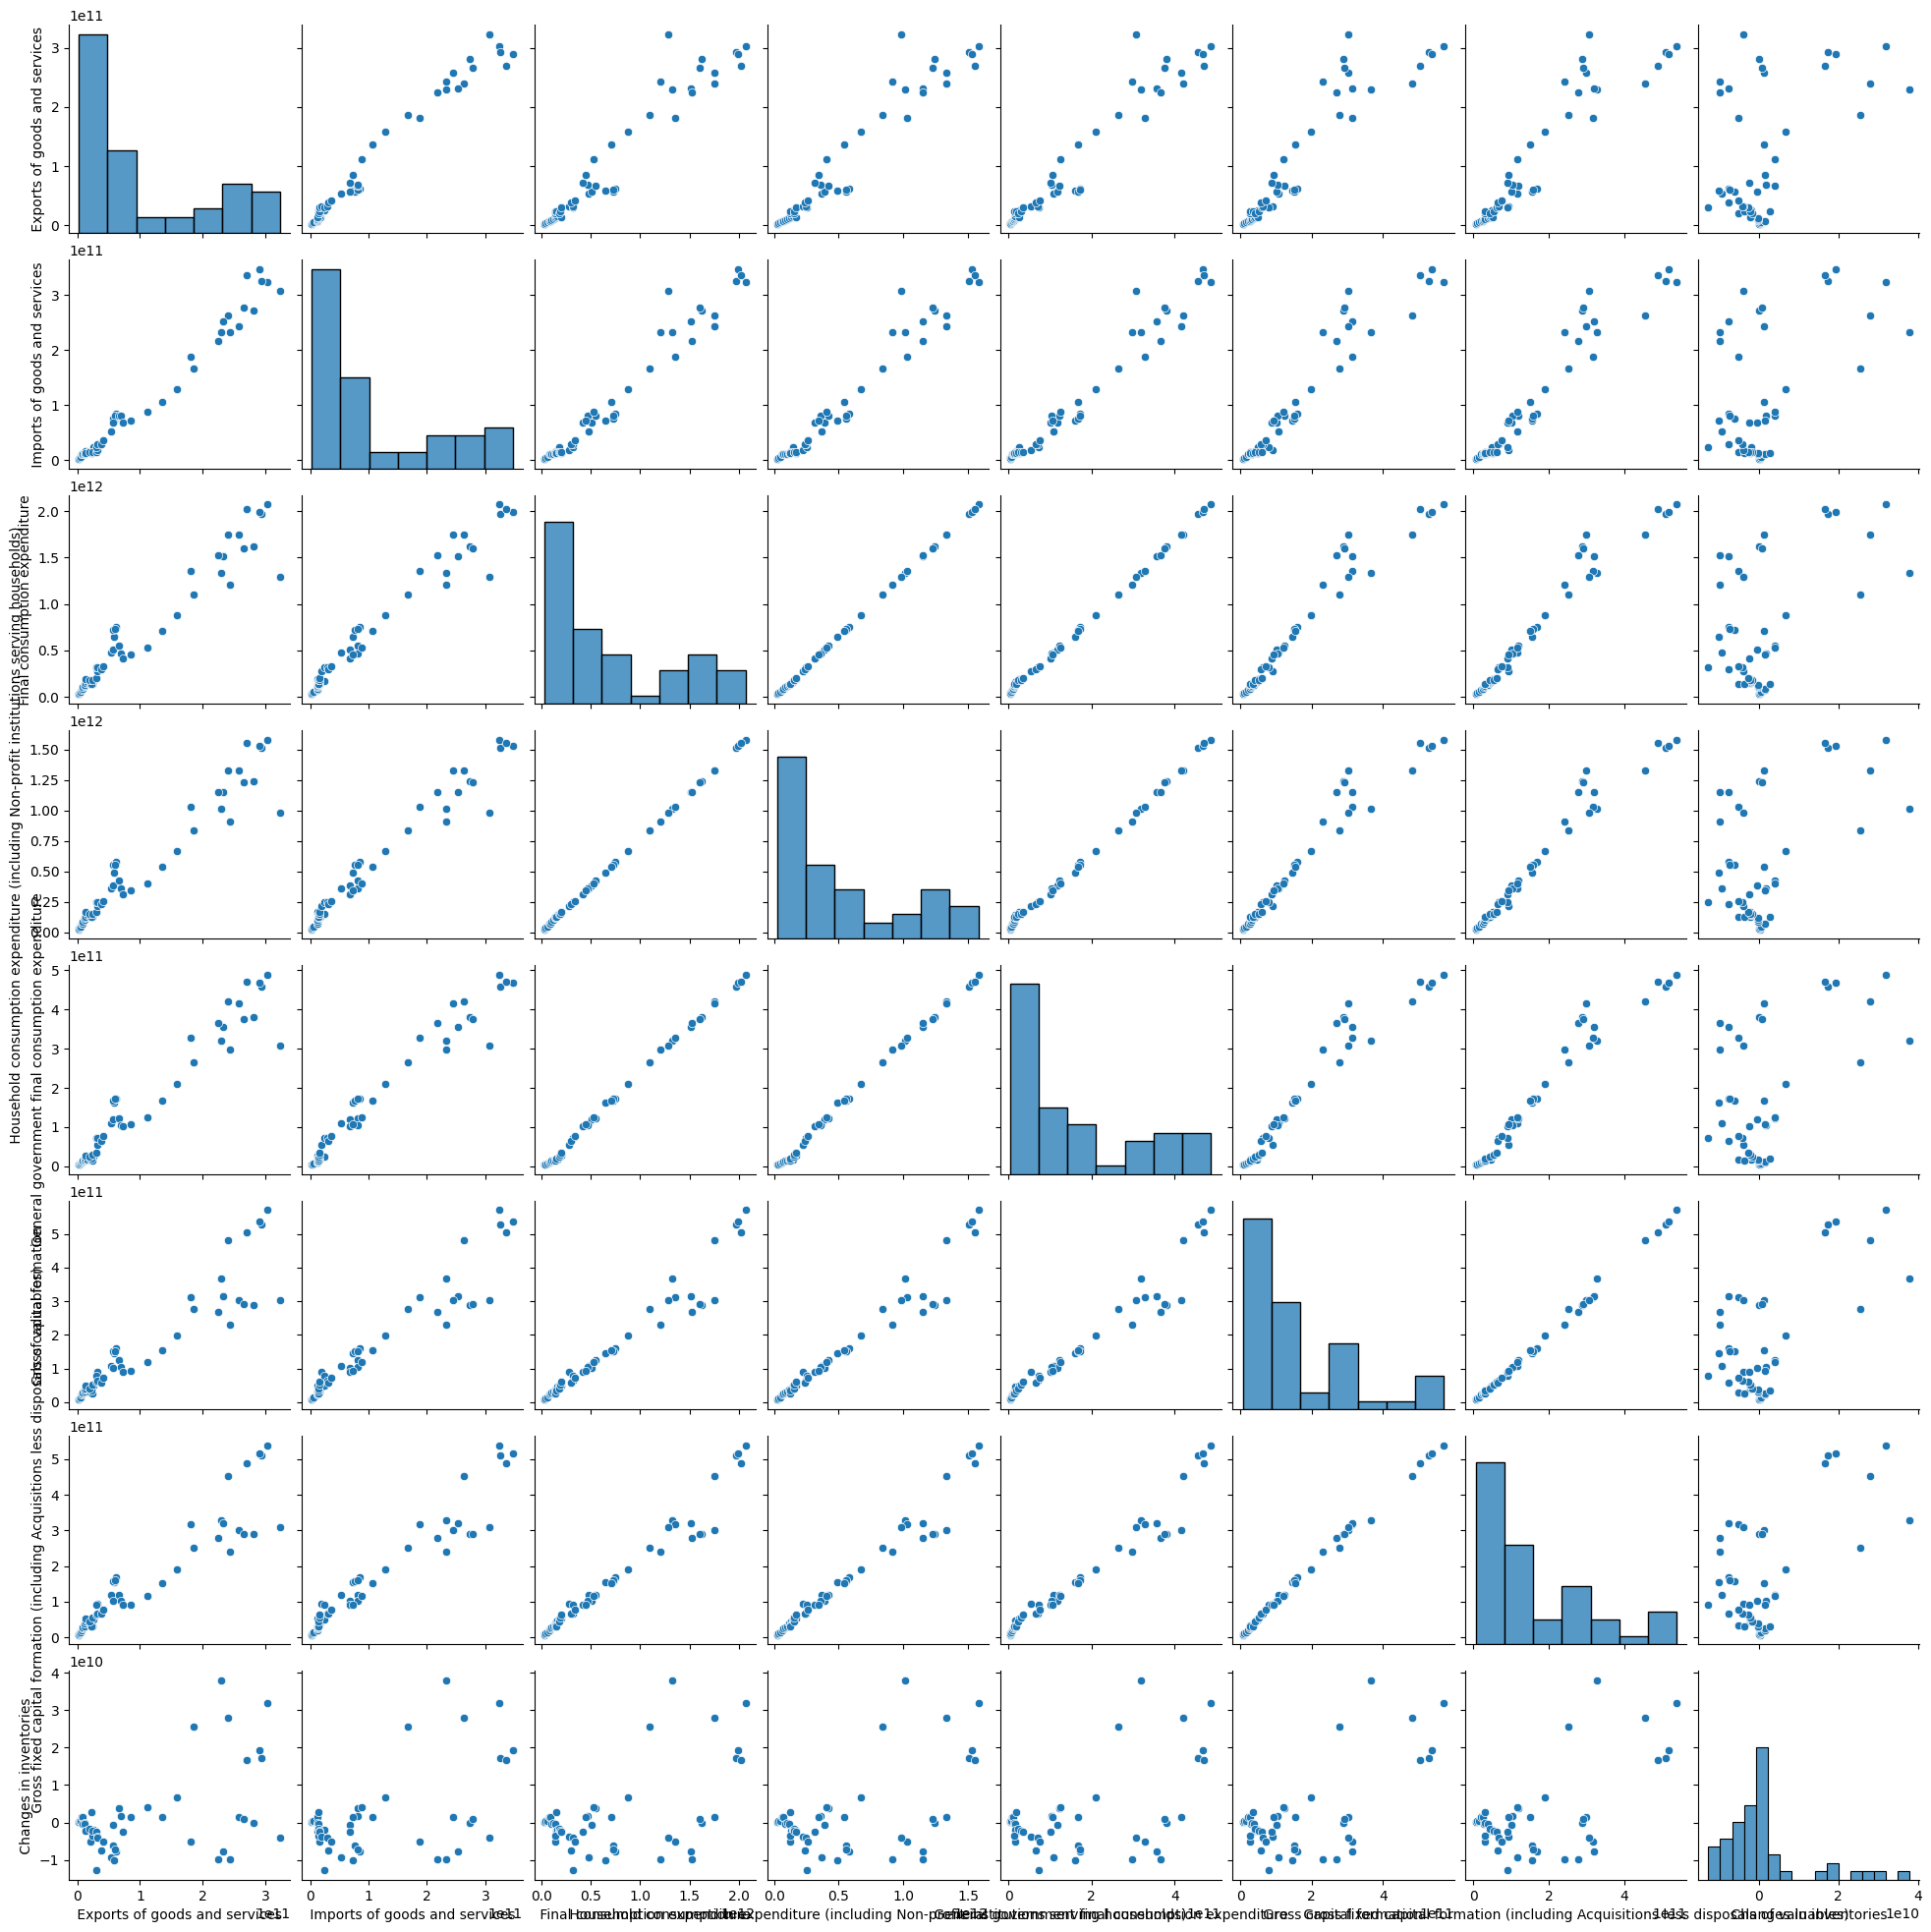

In [8]:
sns.pairplot(df_eco_brésil[composantes_pib])
plt.show()

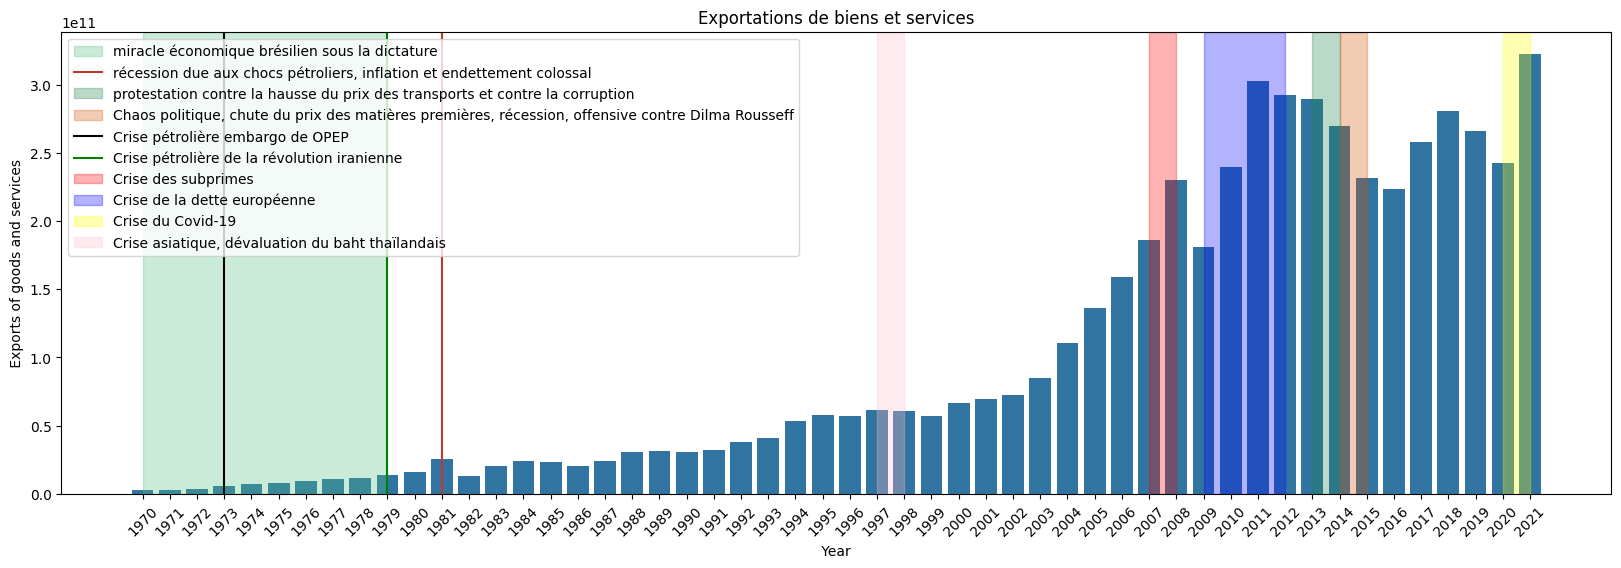

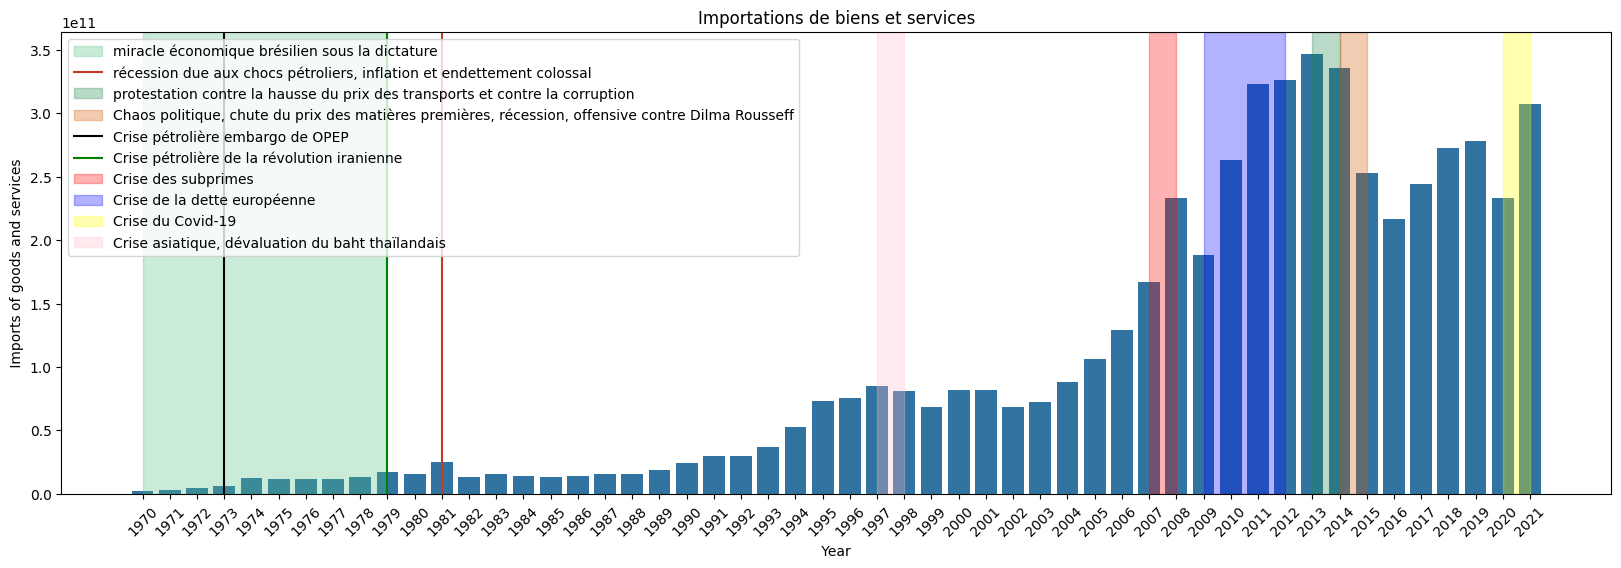

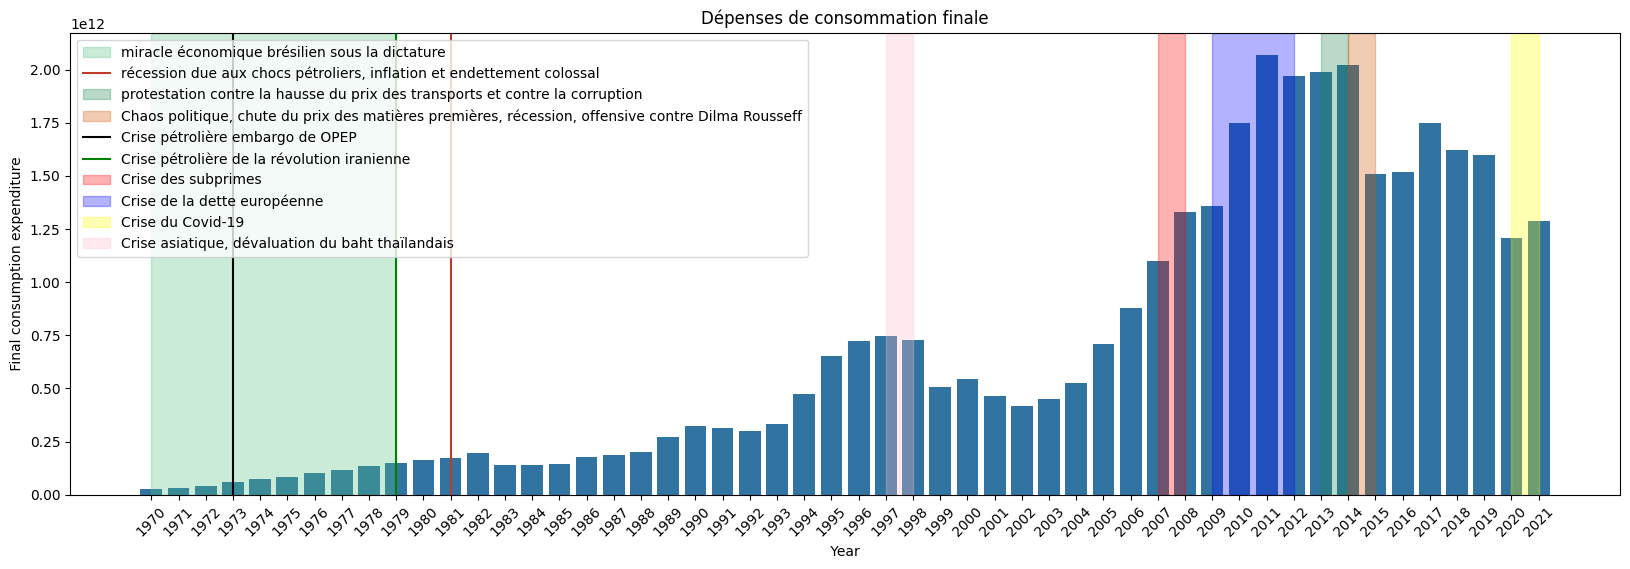

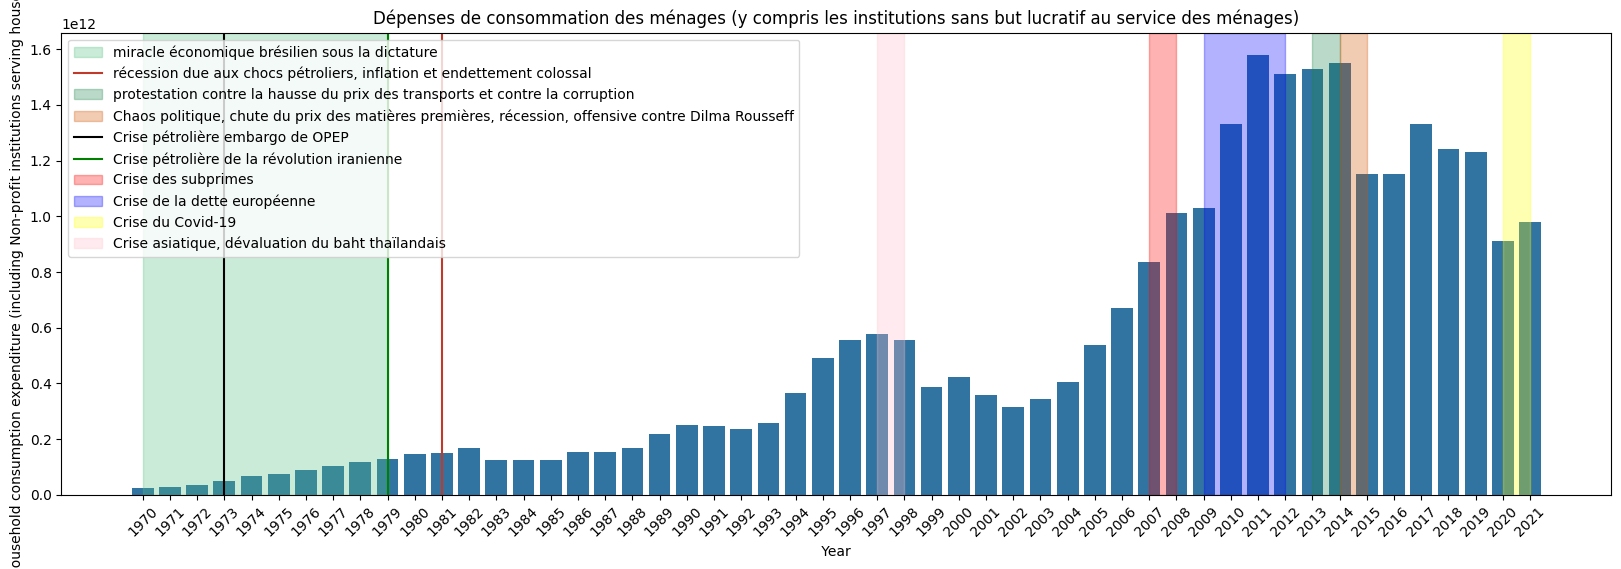

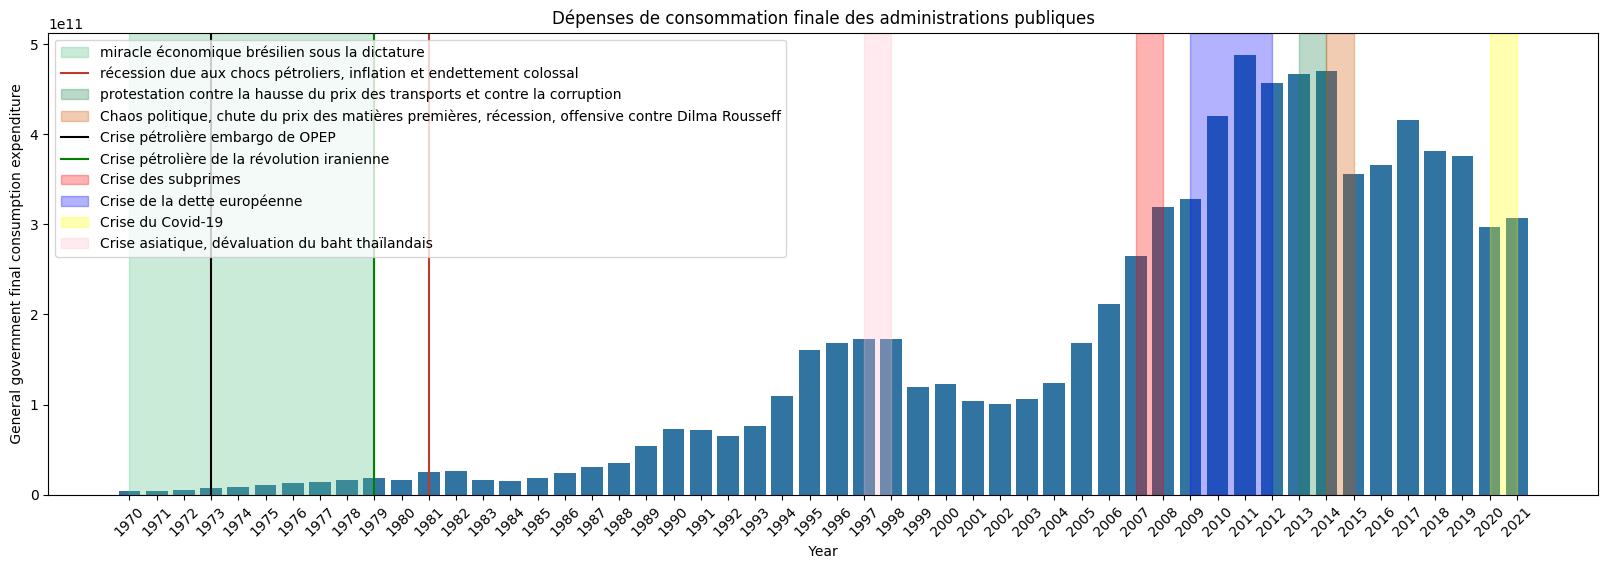

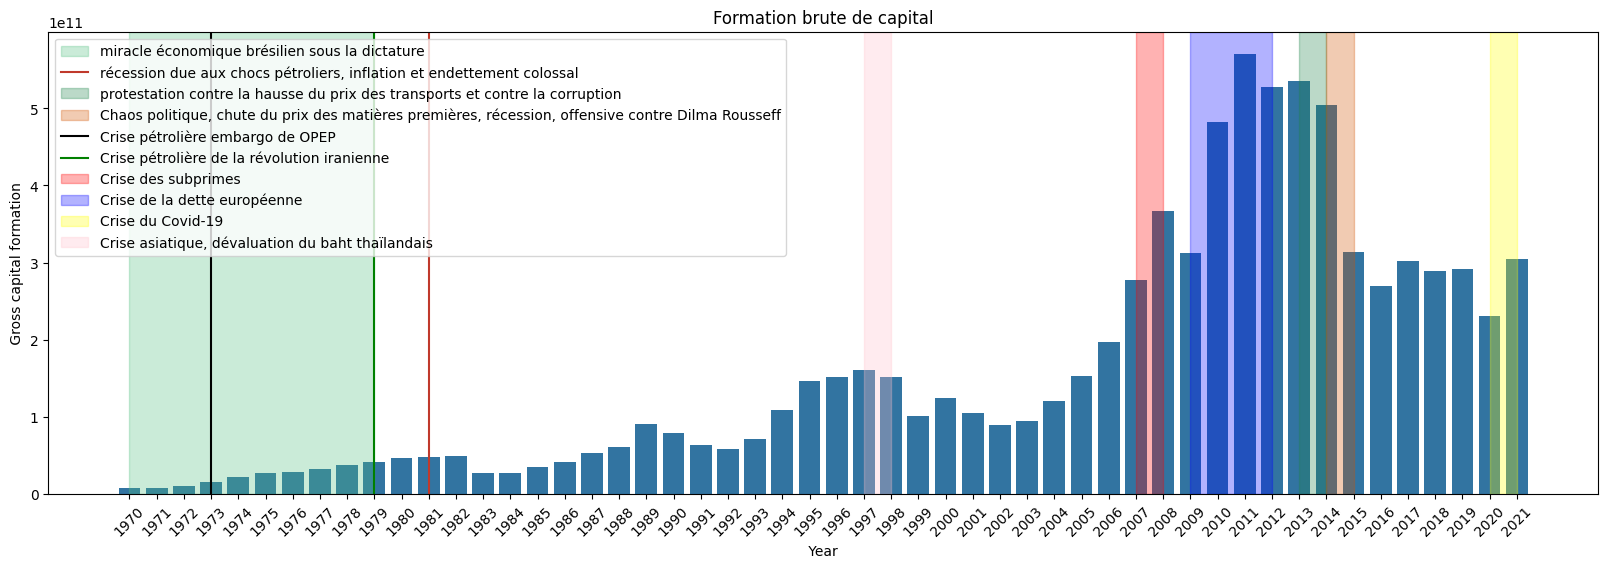

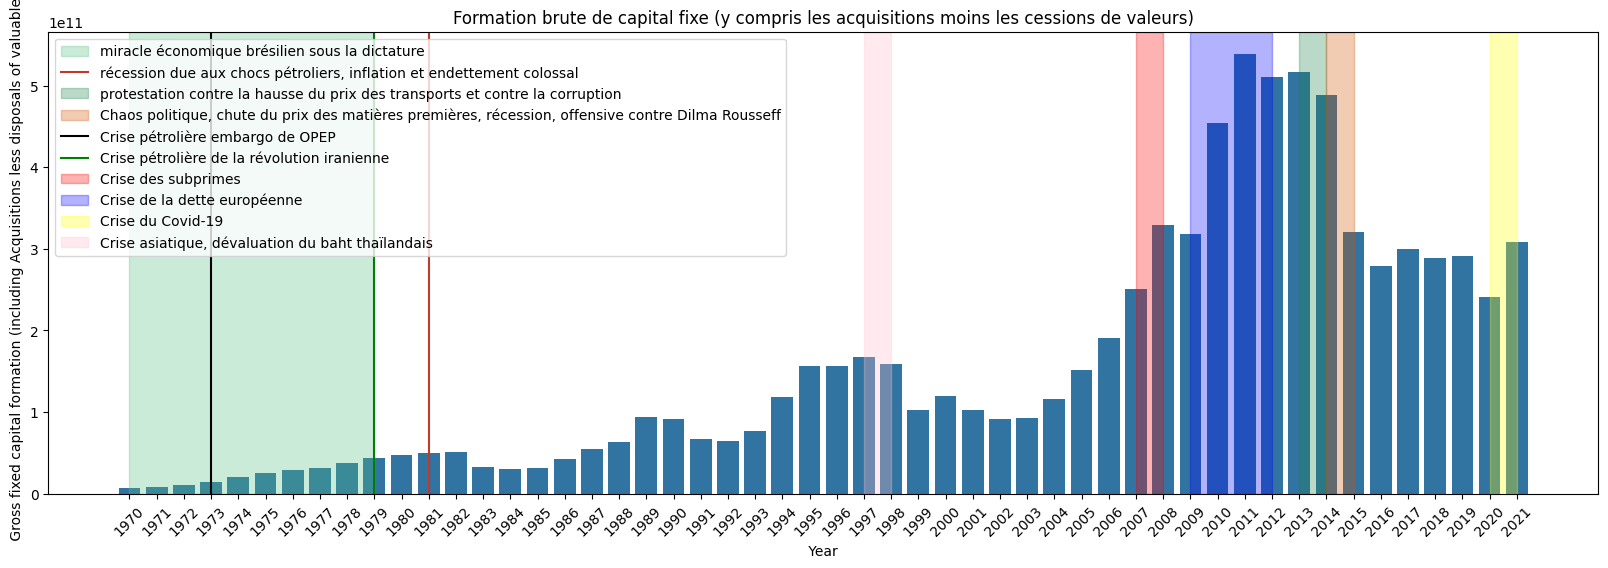

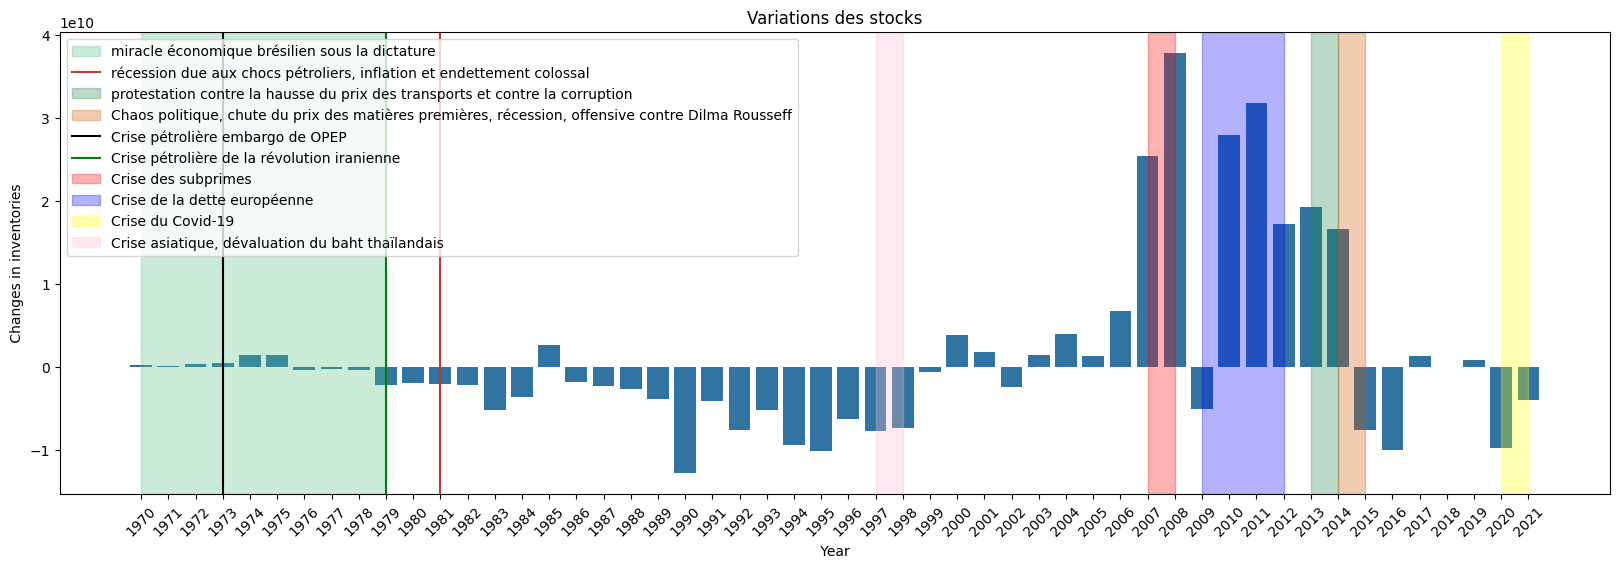

In [9]:
Year=df_eco_brésil[' Year '].tolist() 

#On commence par lister les crises pour les faire apparaître sur notre barplot
miracle_d=Year.index(1970)
miracle_f=Year.index(1979)

recession=Year.index(1981)

protestation_d=Year.index(2013)
protestation_f=Year.index(2014)

chaos_d=Year.index(2014)
chaos_f=Year.index(2015)

petrole_OPEP=Year.index(1973)

petrole_iran=Year.index(1979)

asiatic_crisis_d=Year.index(1997)
asiatic_crisis_f=Year.index(1998)

subprime_d=Year.index(2007)
subprime_f=Year.index(2008)

dette_européenne_d=Year.index(2009)
dette_européenne_f=Year.index(2012)

covid_d=Year.index(2020)
covid_f=Year.index(2021)

for elem in composantes_pib:
    plt.figure(figsize=(20,6))
    sns.barplot(x=df_eco_brésil[' Year '], y=df_eco_brésil[elem])

    plt.axvspan(miracle_d, miracle_f, color='#52be80', alpha=0.3, label='miracle économique brésilien sous la dictature')
    plt.axvline(x=recession, color='#c0392b', linestyle='-', label='récession due aux chocs pétroliers, inflation et endettement colossal')
    plt.axvspan(protestation_d, protestation_f, color='#1e8449', alpha=0.3, label='protestation contre la hausse du prix des transports et contre la corruption')
    plt.axvspan(chaos_d, chaos_f, color='#d35400', alpha=0.3, 
                label='Chaos politique, chute du prix des matières premières, récession, offensive contre Dilma Rousseff')

    plt.axvline(x=petrole_OPEP, color='black', linestyle='-', label='Crise pétrolière embargo de OPEP')
    plt.axvline(x=petrole_iran, color='green', linestyle='-', label='Crise pétrolière de la révolution iranienne')
    plt.axvspan(subprime_d, subprime_f, color='red',alpha=0.3,  label='Crise des subprimes')
    plt.axvspan(dette_européenne_d, dette_européenne_f, color='blue', alpha=0.3, label='Crise de la dette européenne')
    plt.axvspan(covid_d, covid_f, color='yellow', alpha=0.3, label='Crise du Covid-19')
    plt.axvspan(asiatic_crisis_d, asiatic_crisis_f, color='pink', alpha=0.3, label='Crise asiatique, dévaluation du baht thaïlandais')

    titre=traduction.get(elem, elem)
    plt.title(f'{titre}')
    plt.xticks(rotation=45)
    plt.legend()

plt.show()

## Secteurs Économiques

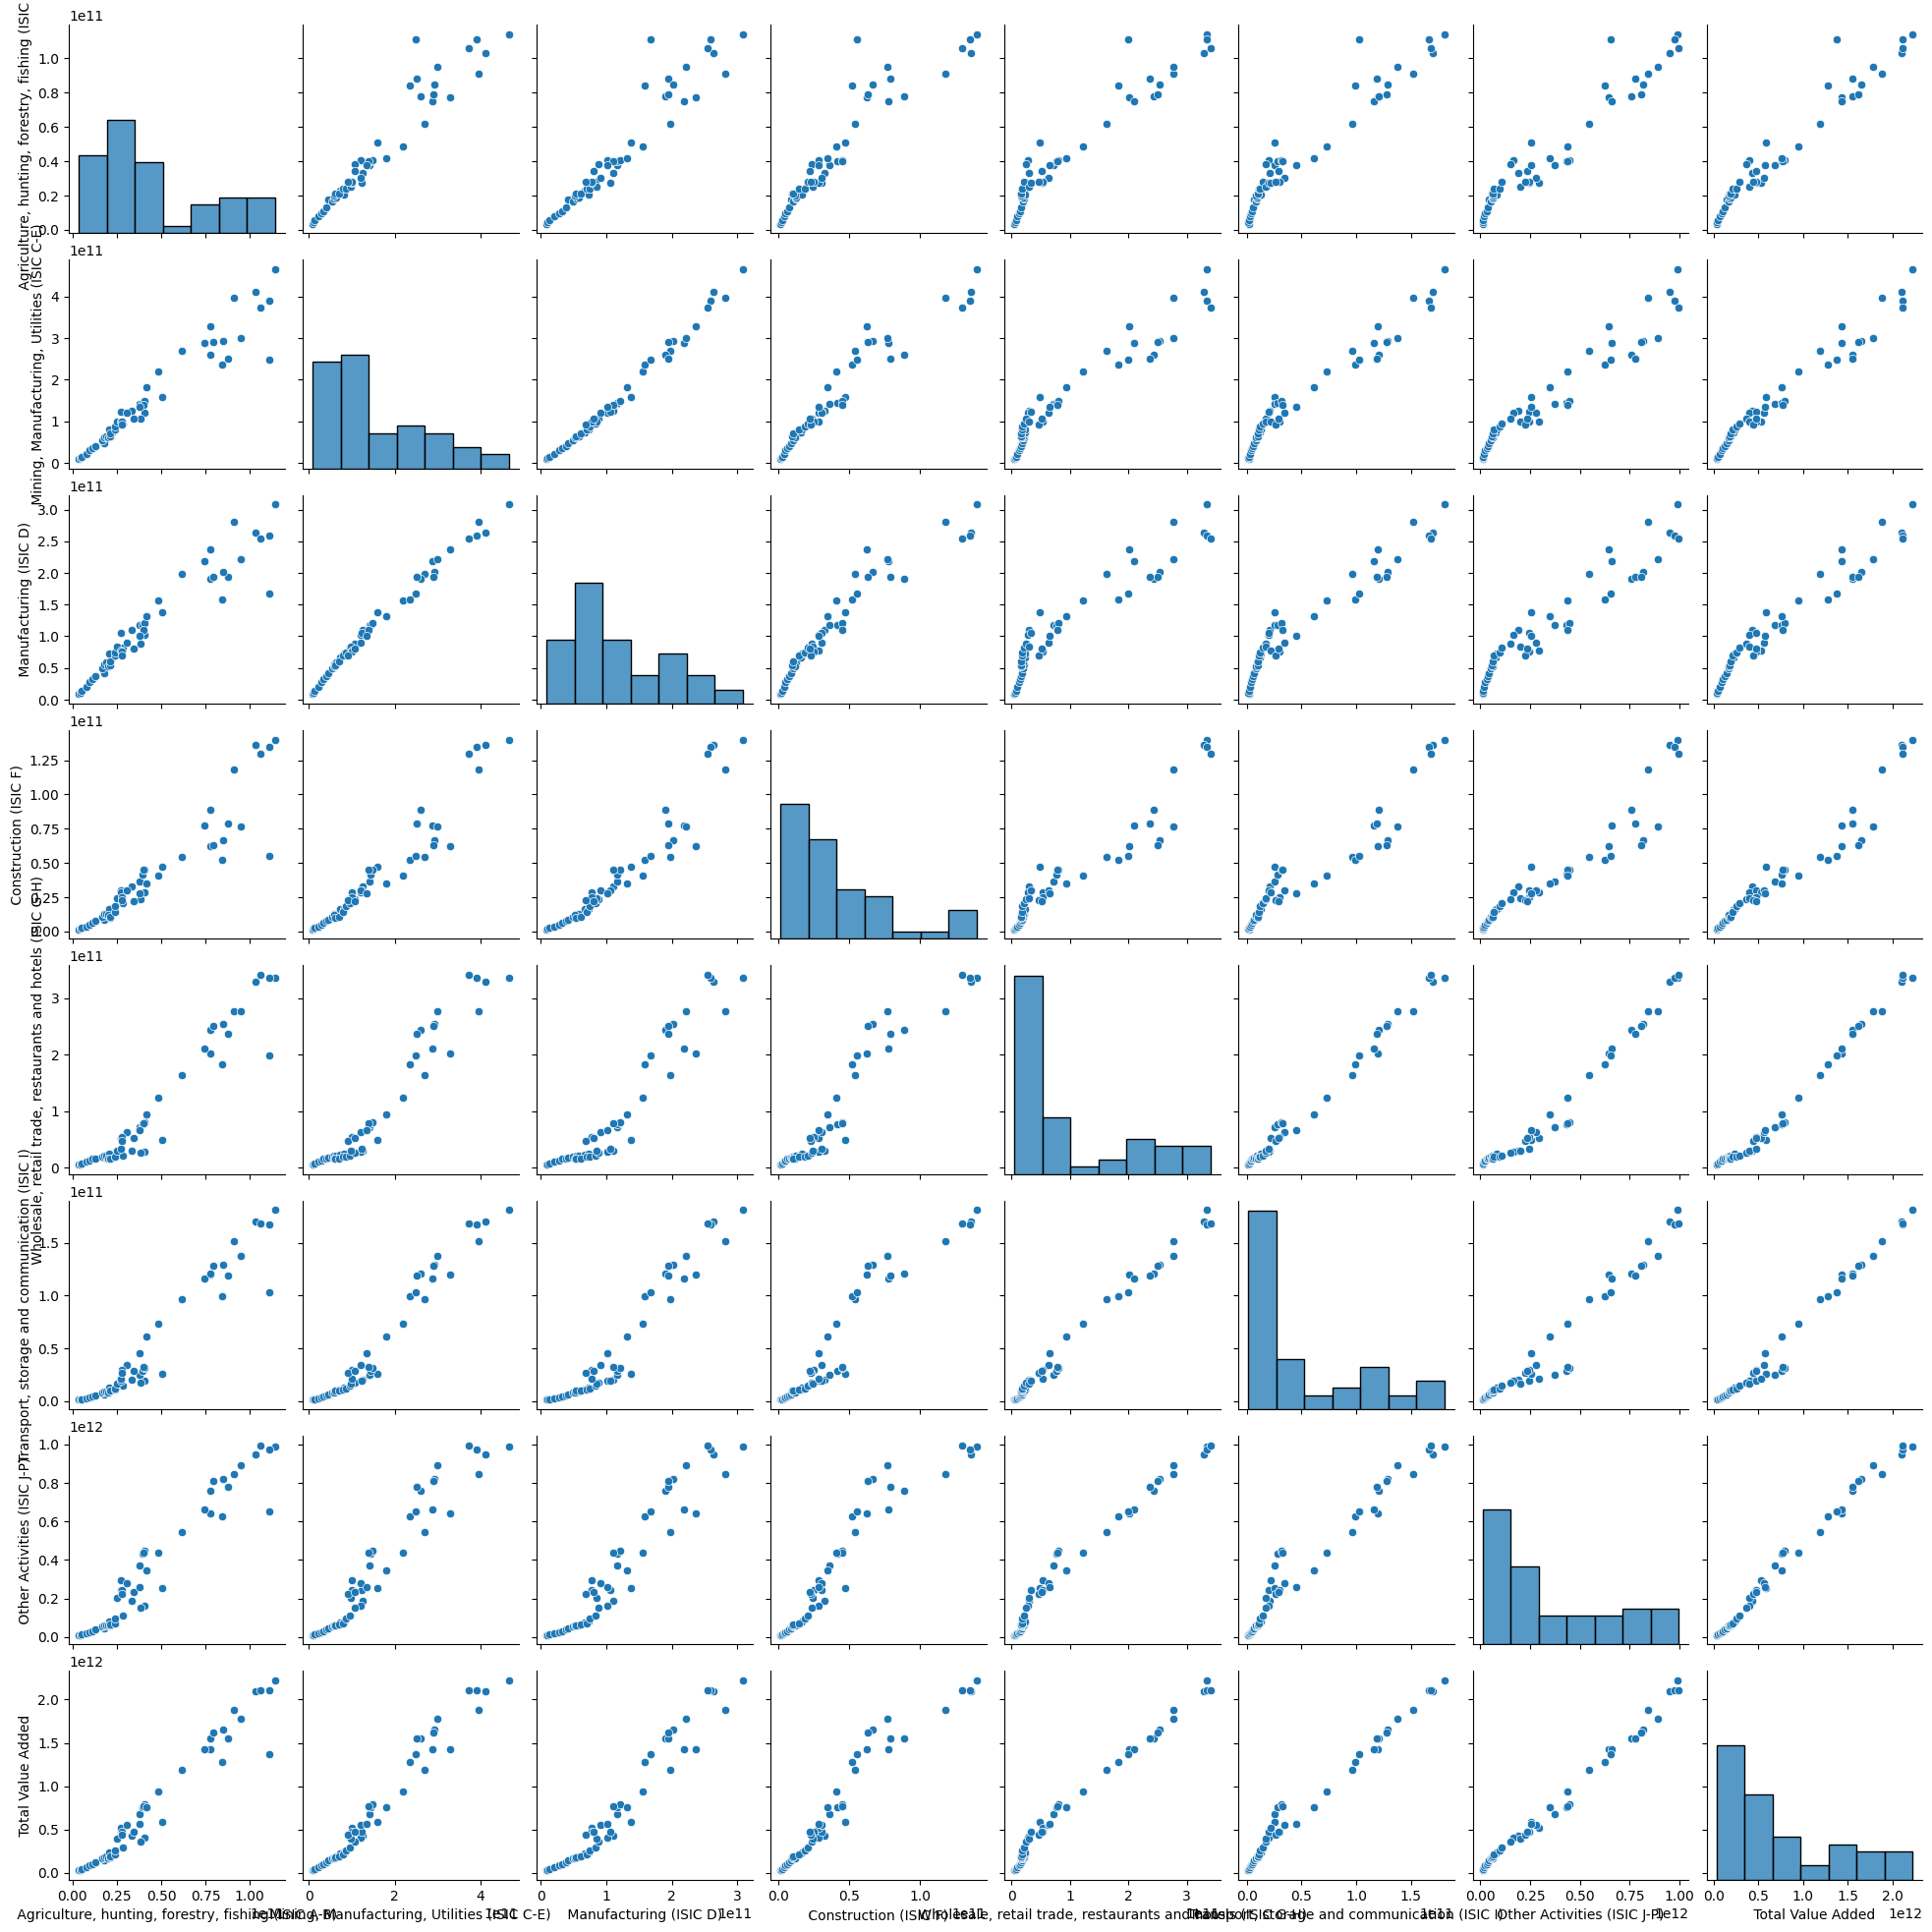

In [10]:
sns.pairplot(df_eco_brésil[secteurs_economiques])
plt.show()

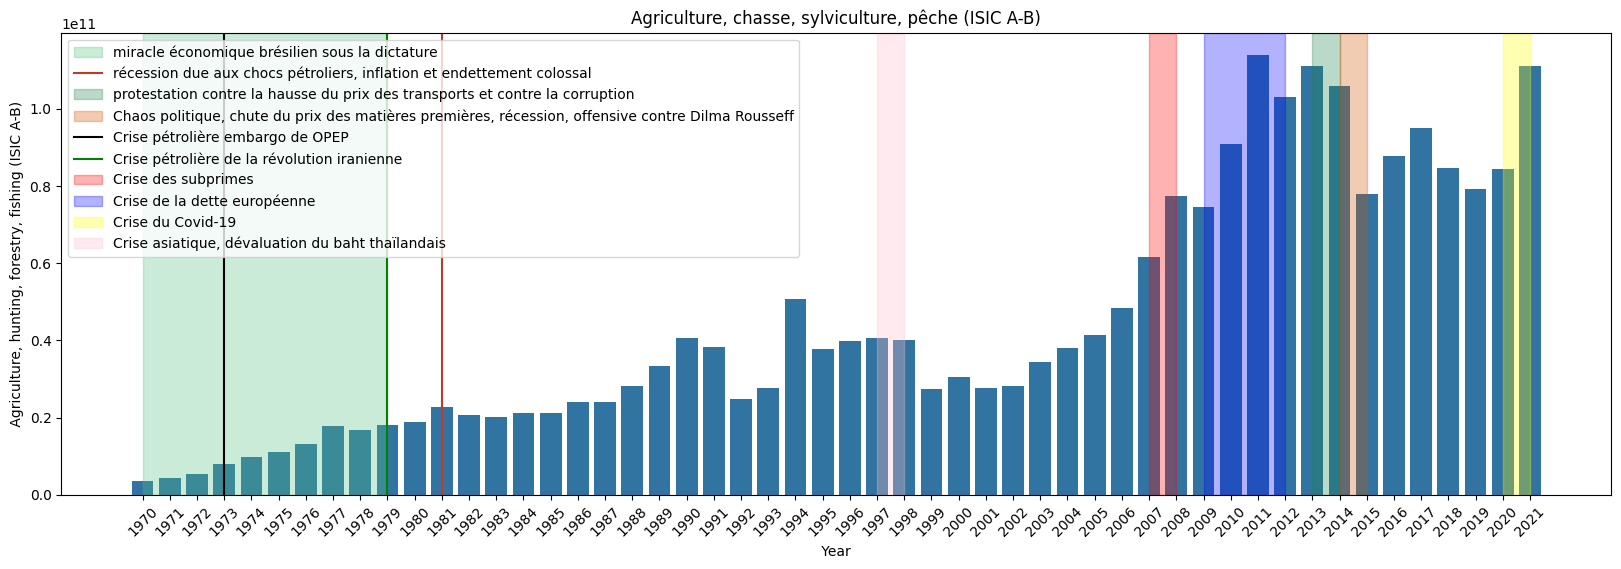

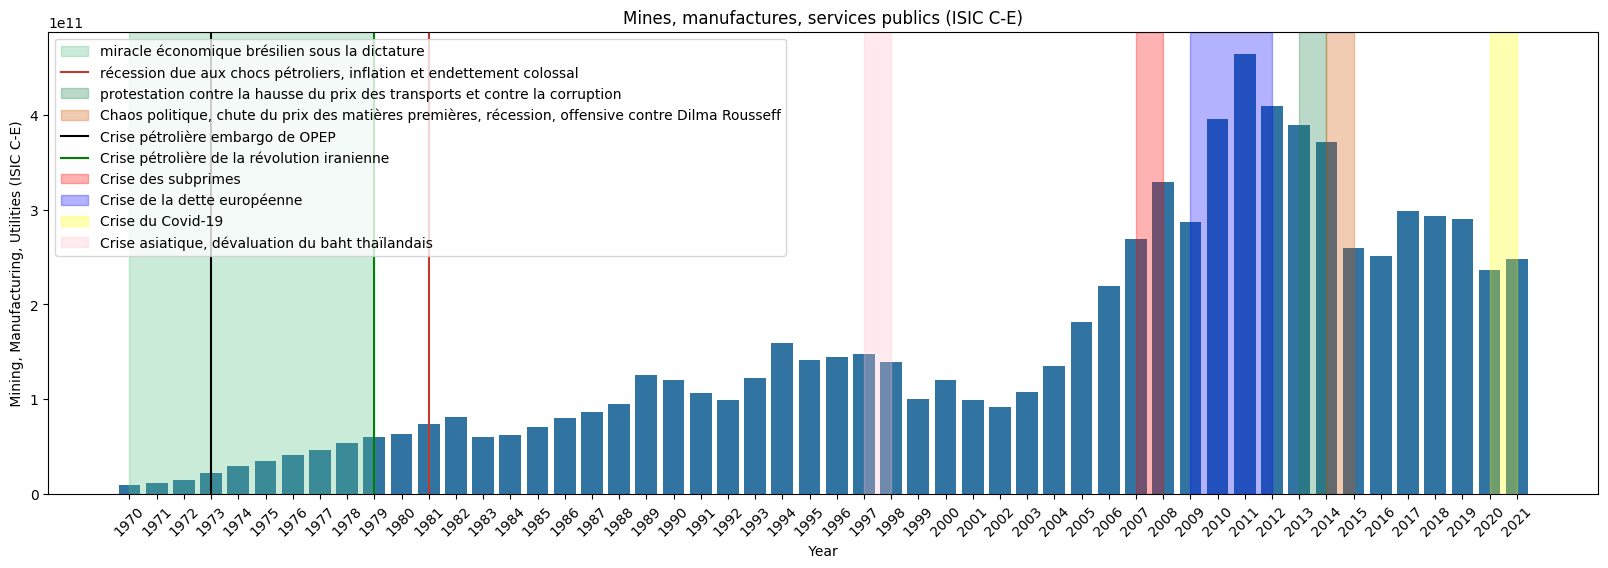

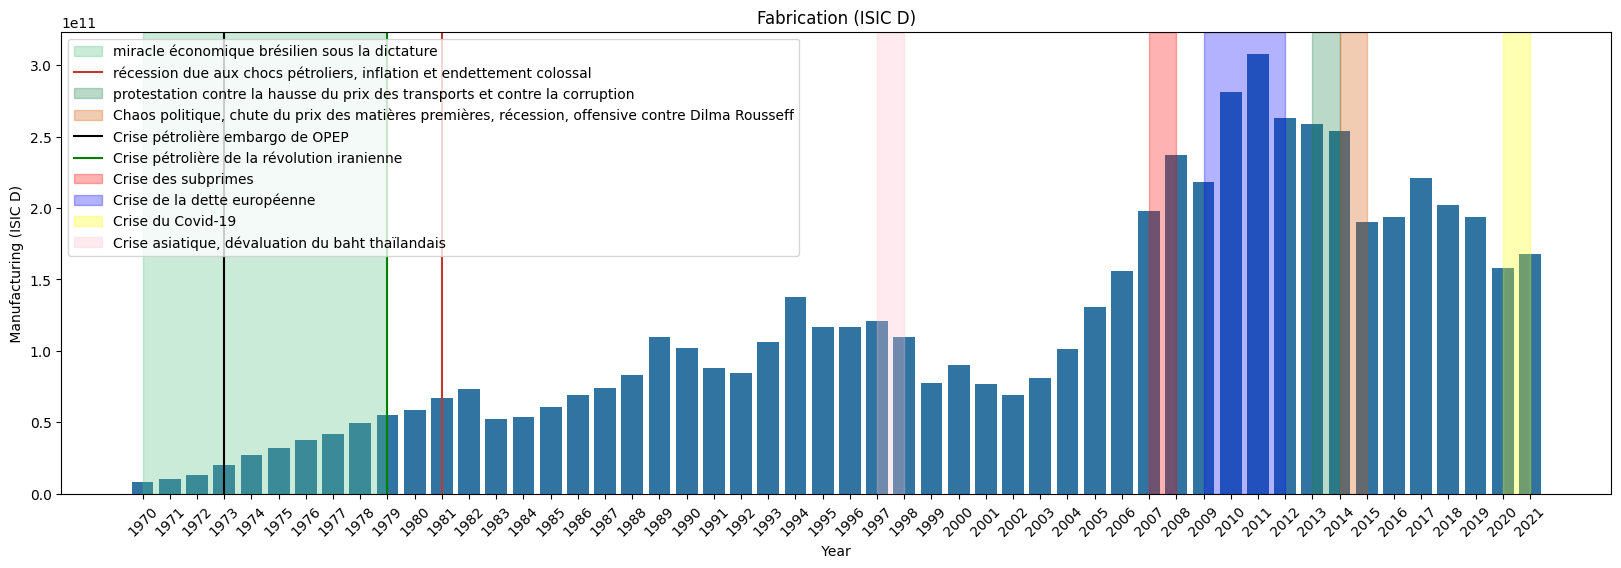

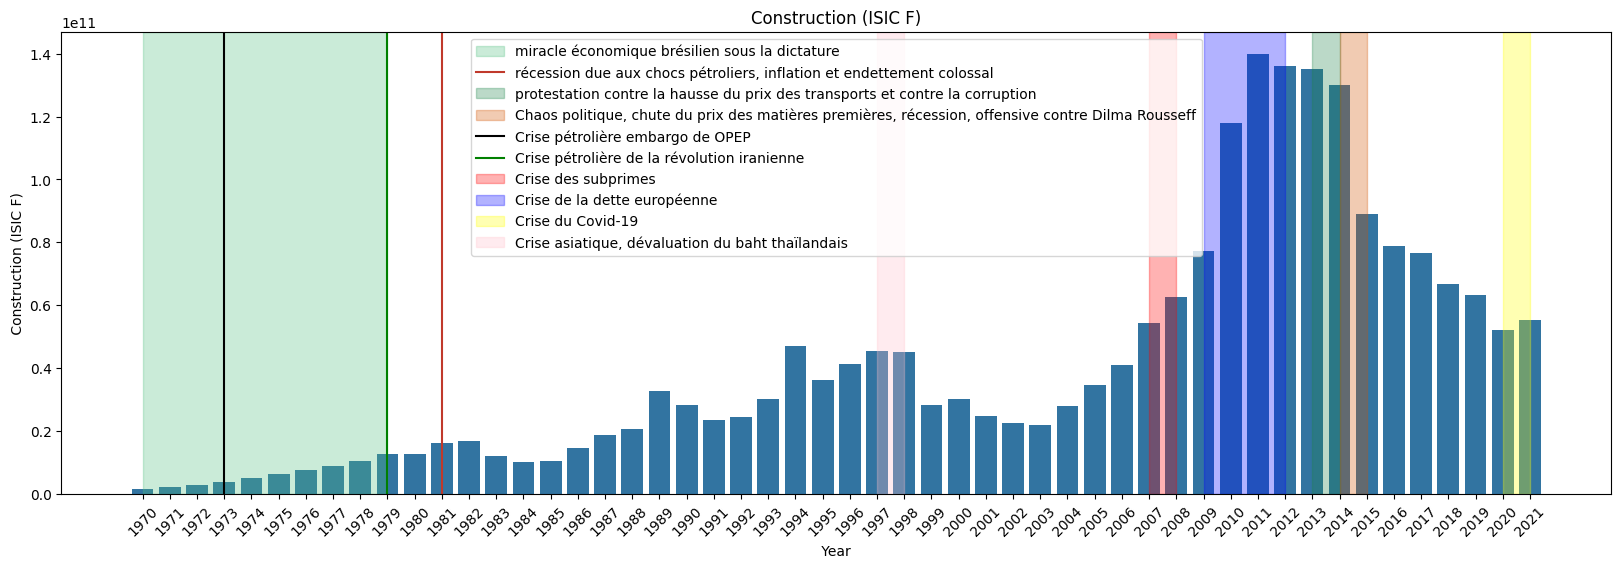

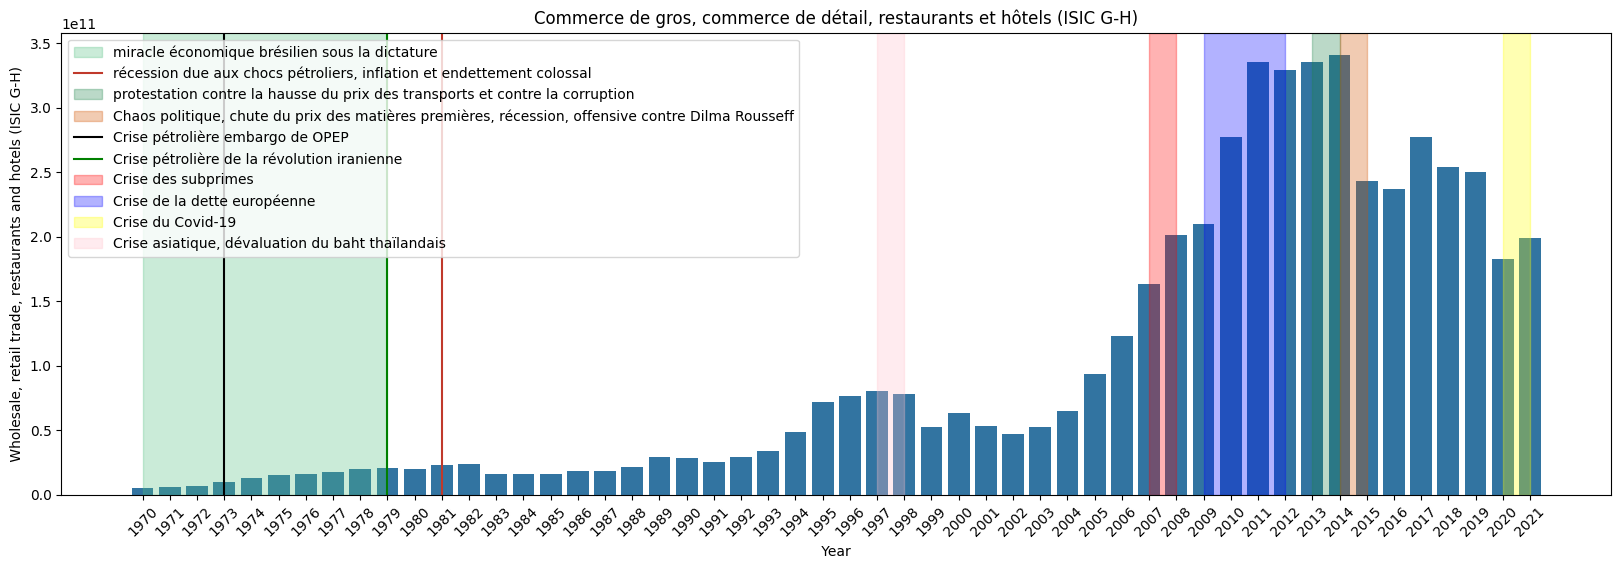

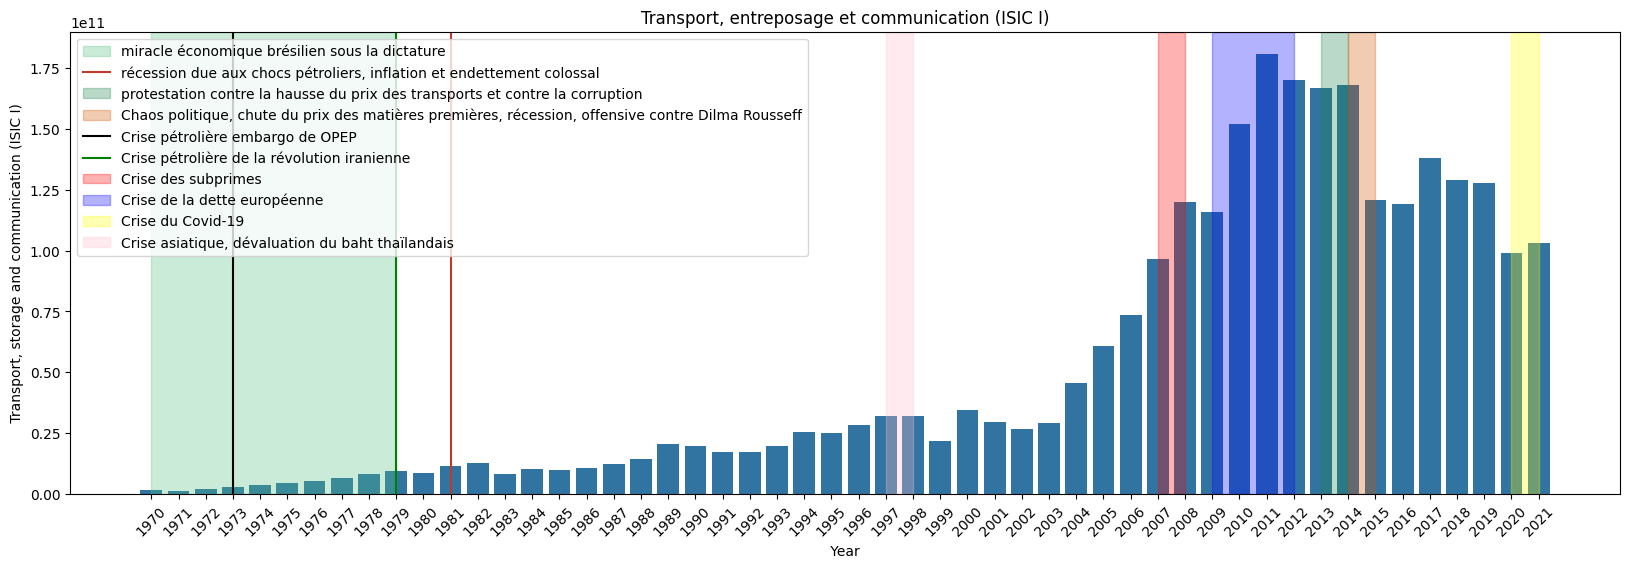

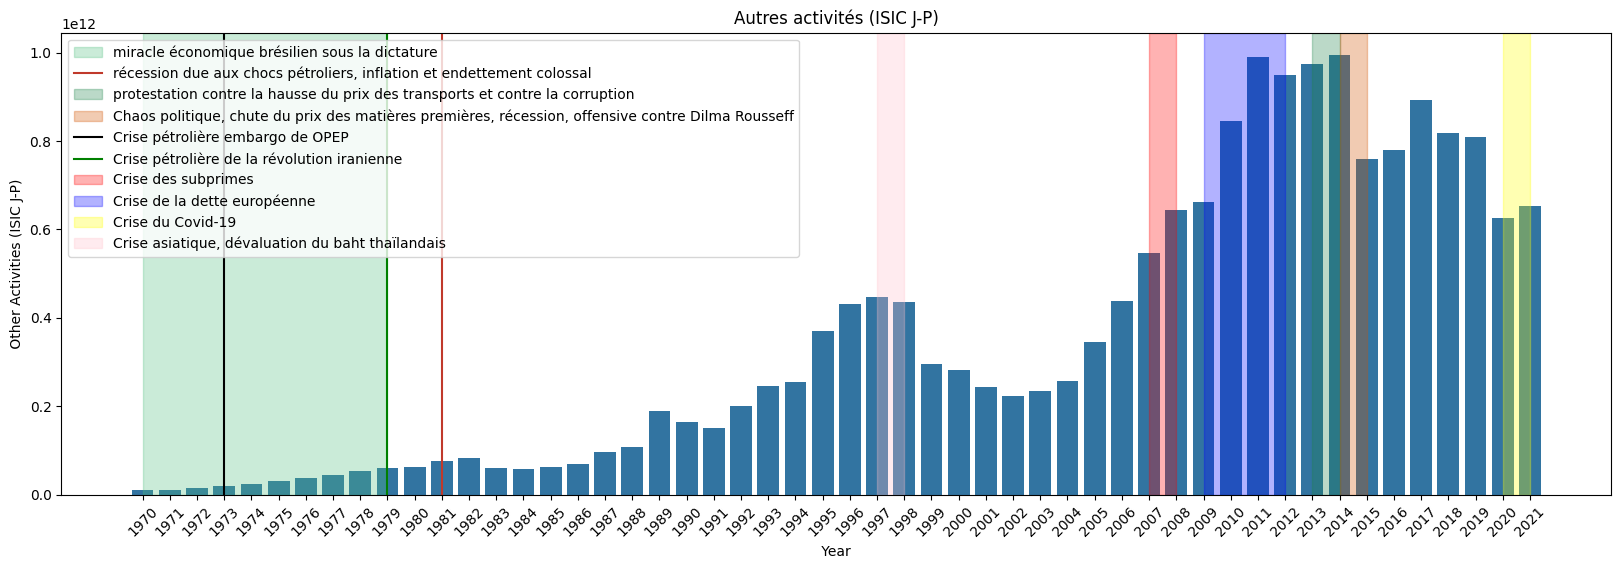

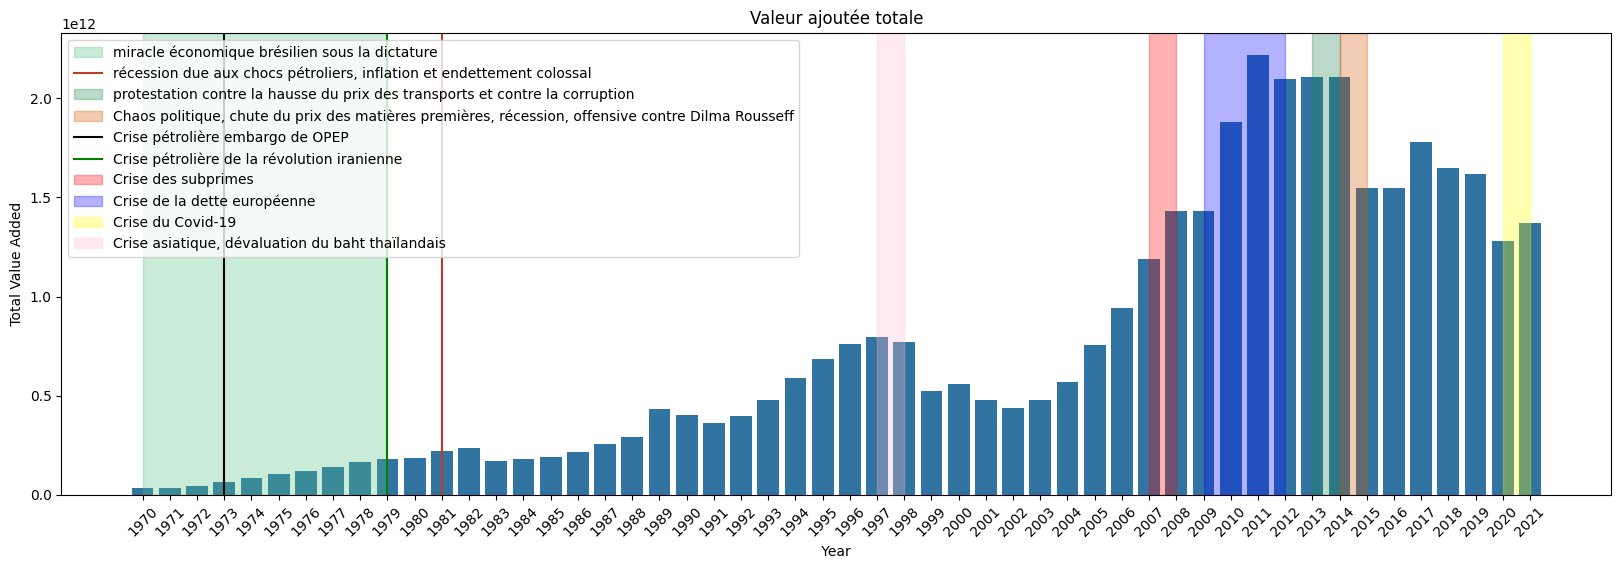

In [11]:
for elem in secteurs_economiques:
    plt.figure(figsize=(20,6))
    sns.barplot(x=df_eco_brésil[' Year '], y=df_eco_brésil[elem])

    plt.axvspan(miracle_d, miracle_f, color='#52be80', alpha=0.3, label='miracle économique brésilien sous la dictature')
    plt.axvline(x=recession, color='#c0392b', linestyle='-', label='récession due aux chocs pétroliers, inflation et endettement colossal')
    plt.axvspan(protestation_d, protestation_f, color='#1e8449', alpha=0.3, label='protestation contre la hausse du prix des transports et contre la corruption')
    plt.axvspan(chaos_d, chaos_f, color='#d35400', alpha=0.3, 
                label='Chaos politique, chute du prix des matières premières, récession, offensive contre Dilma Rousseff')
    
    plt.axvline(x=petrole_OPEP, color='black', linestyle='-', label='Crise pétrolière embargo de OPEP')
    plt.axvline(x=petrole_iran, color='green', linestyle='-', label='Crise pétrolière de la révolution iranienne')
    plt.axvspan(subprime_d, subprime_f, color='red',alpha=0.3,  label='Crise des subprimes')
    plt.axvspan(dette_européenne_d, dette_européenne_f, color='blue', alpha=0.3, label='Crise de la dette européenne')
    plt.axvspan(covid_d, covid_f, color='yellow', alpha=0.3, label='Crise du Covid-19')
    plt.axvspan(asiatic_crisis_d, asiatic_crisis_f, color='pink', alpha=0.3, label='Crise asiatique, dévaluation du baht thaïlandais')

    titre=traduction.get(elem, elem)
    plt.title(f'{titre}')
    plt.xticks(rotation=45)
    plt.legend()

plt.show()